# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-8

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model8_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

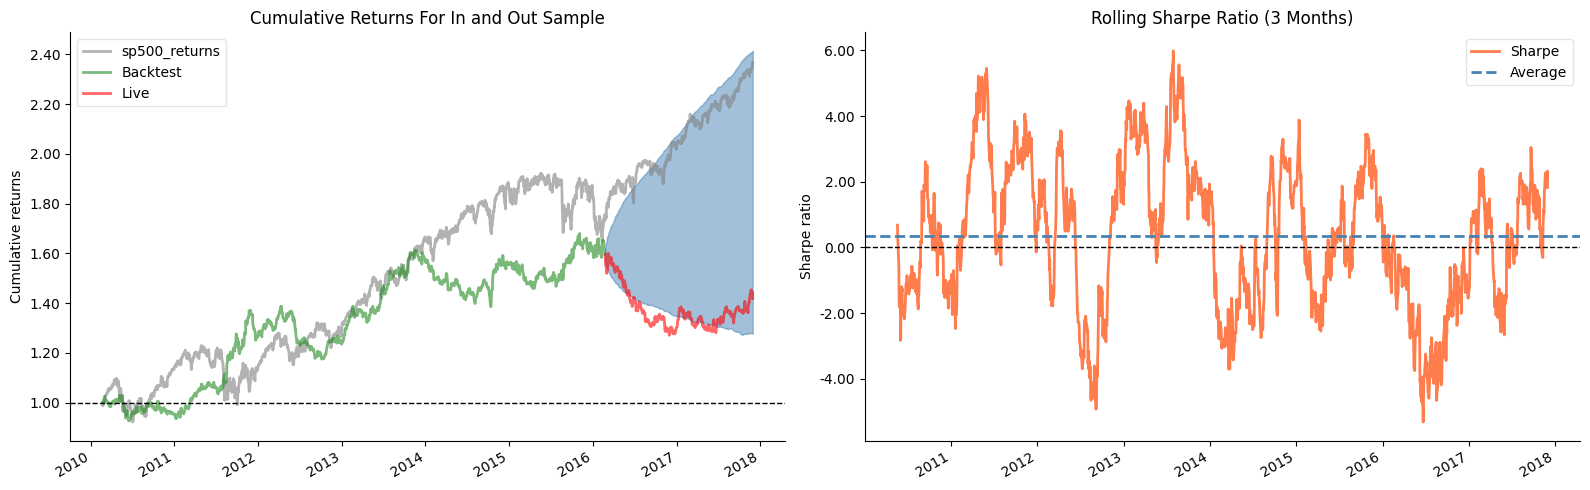

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,24.34,2015-11-05,2016-11-30,NaT,NaN
1,15.29,2012-04-12,2012-10-05,2013-02-19,224
2,14.11,2013-11-21,2014-10-13,2015-10-02,487
3,10.02,2010-05-19,2010-06-16,2011-03-30,226
4,8.84,2011-11-29,2011-12-22,2012-04-09,95


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.52%,-1.87%,5.44%
Fukushima,0.14%,-0.78%,0.96%
EZB IR Event,-0.00%,-0.80%,1.80%
Flash Crash,0.20%,-0.70%,0.85%
Apr14,-0.04%,-1.83%,1.21%
Oct14,0.20%,-1.55%,2.89%
Fall2015,0.17%,-1.83%,3.57%
Recovery,0.03%,-3.37%,5.44%
New Normal,0.01%,-3.18%,3.57%


Top 10 long positions of all time,max
sid,
EXPD,45.06%
PODD,43.00%
NVDA,39.27%
WTW,31.84%
URI,22.73%
FFIV,22.17%
EXC,21.31%
STLD,20.90%
NTAP,20.80%


Top 10 short positions of all time,max
sid,
NVDA,-45.27%
EXPD,-41.11%
PODD,-38.86%
URI,-28.52%
WTW,-26.52%
NFLX,-26.41%
APD,-23.97%
ALB,-22.06%
MGM,-21.03%


Top 10 positions of all time,max
sid,
NVDA,45.27%
EXPD,45.06%
PODD,43.00%
WTW,31.84%
URI,28.52%
NFLX,26.41%
APD,23.97%
FFIV,22.17%
ALB,22.06%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1083281.29,$-1049988.41,$2133269.71
Gross profit,$29864439.02,$13541880.98,$16322558.04
Gross loss,$-28781157.73,$-14591869.39,$-14189288.34
Profit factor,$1.04,$0.93,$1.15
Avg. trade net profit,$14.11,$-28.00,$54.29
Avg. winning trade,$777.44,$752.08,$799.81
Avg. losing trade,$-761.97,$-759.56,$-764.47
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.05
Largest winning trade,$145442.63,$40036.68,$145442.63
Largest losing trade,$-51459.12,$-16349.50,$-51459.12


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 15:50:31.973446371,1 days 13:35:13.032669280,1 days 17:59:40.208979155
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,398 days 00:00:00,398 days 00:00:00,147 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.04%
Median returns losing,-0.04%,-0.04%,-0.03%
Largest winning trade,9.65%,2.58%,9.65%
Largest losing trade,-3.56%,-1.03%,-3.56%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.02%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.03%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.03%,-0.00%,0.02%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.03%,0.01%,-0.01%,-0.00%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.02%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.03%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.02%,0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.01%,-0.00%,0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.01%,0.00%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.01%,0.10%,-0.00%,0.00%,0.01%,0.01%,-0.01%,0.00%,0.01%,-0.01%,0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,0.02%,0.00%,0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.02%,-0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,0.01%,0.01%,0.01%,0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.00%,0.02%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,0.00%,0.01%,-0.01%,0.01%,0.01%,-0.01%,0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.02%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,0.02%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%
Avg returns 

Profitability (PnL / PnL total) per name,
symbol,
LDOS,36.16%
NVDA,9.43%
BLDR,8.42%
BBY,7.11%
STX,4.67%
RL,4.61%
MNST,4.54%
GIS,4.48%
TAP,4.29%


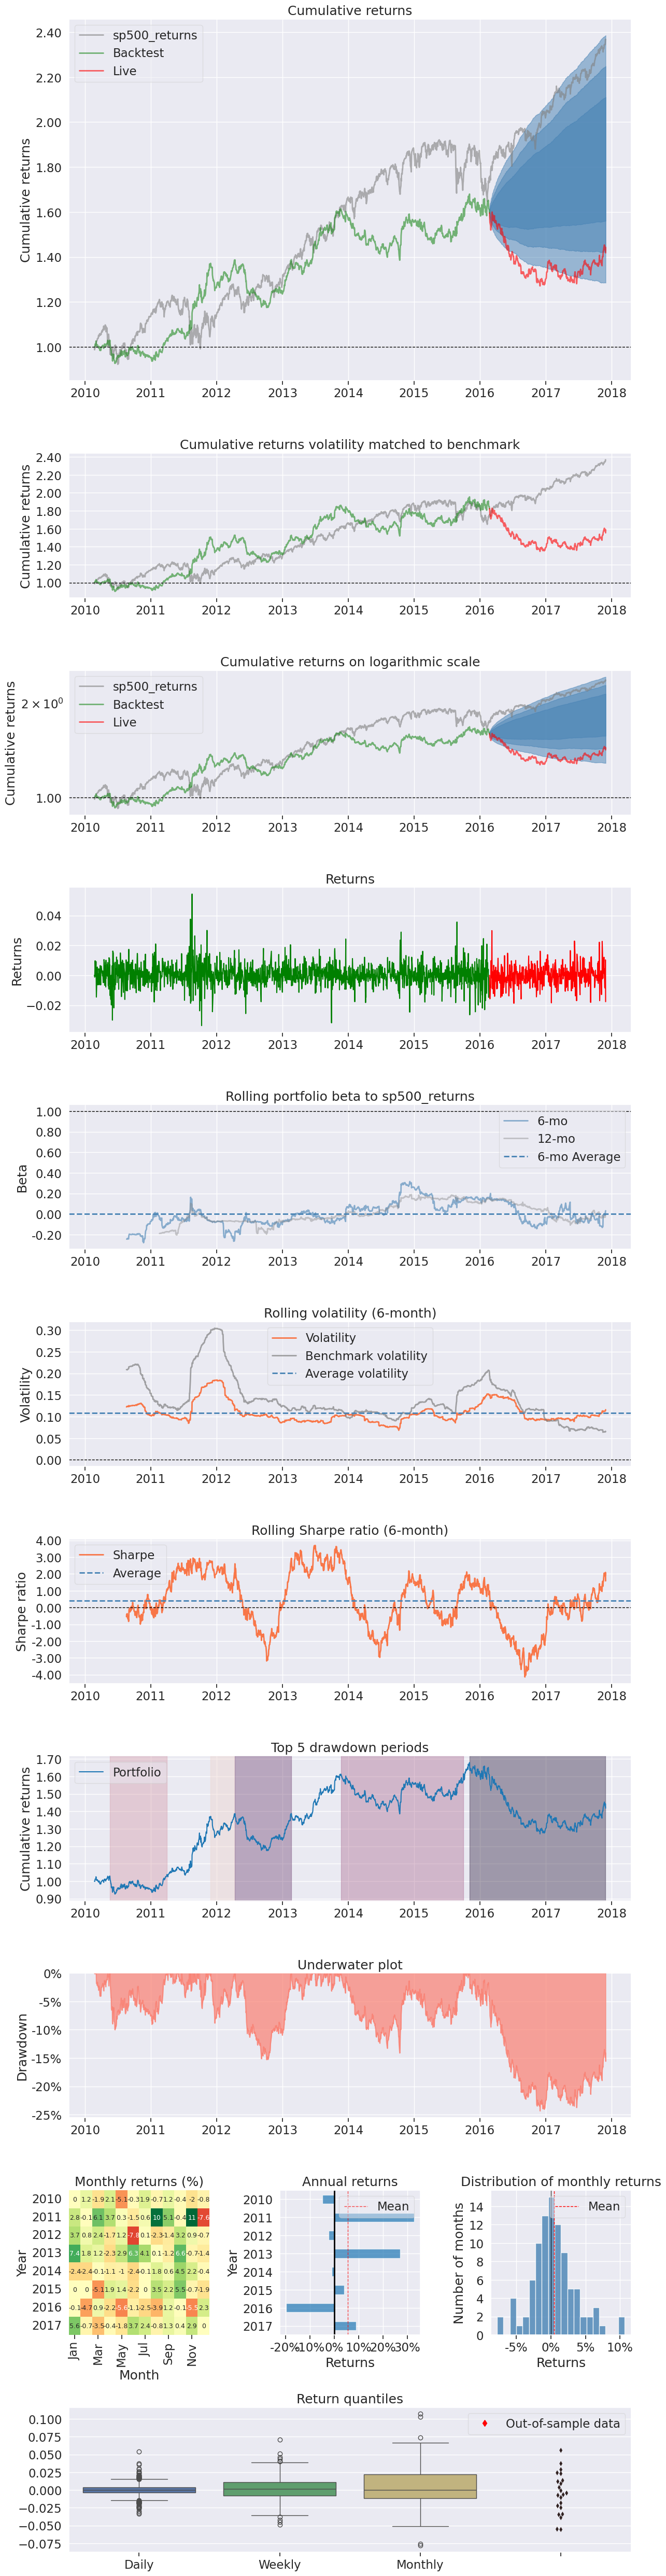

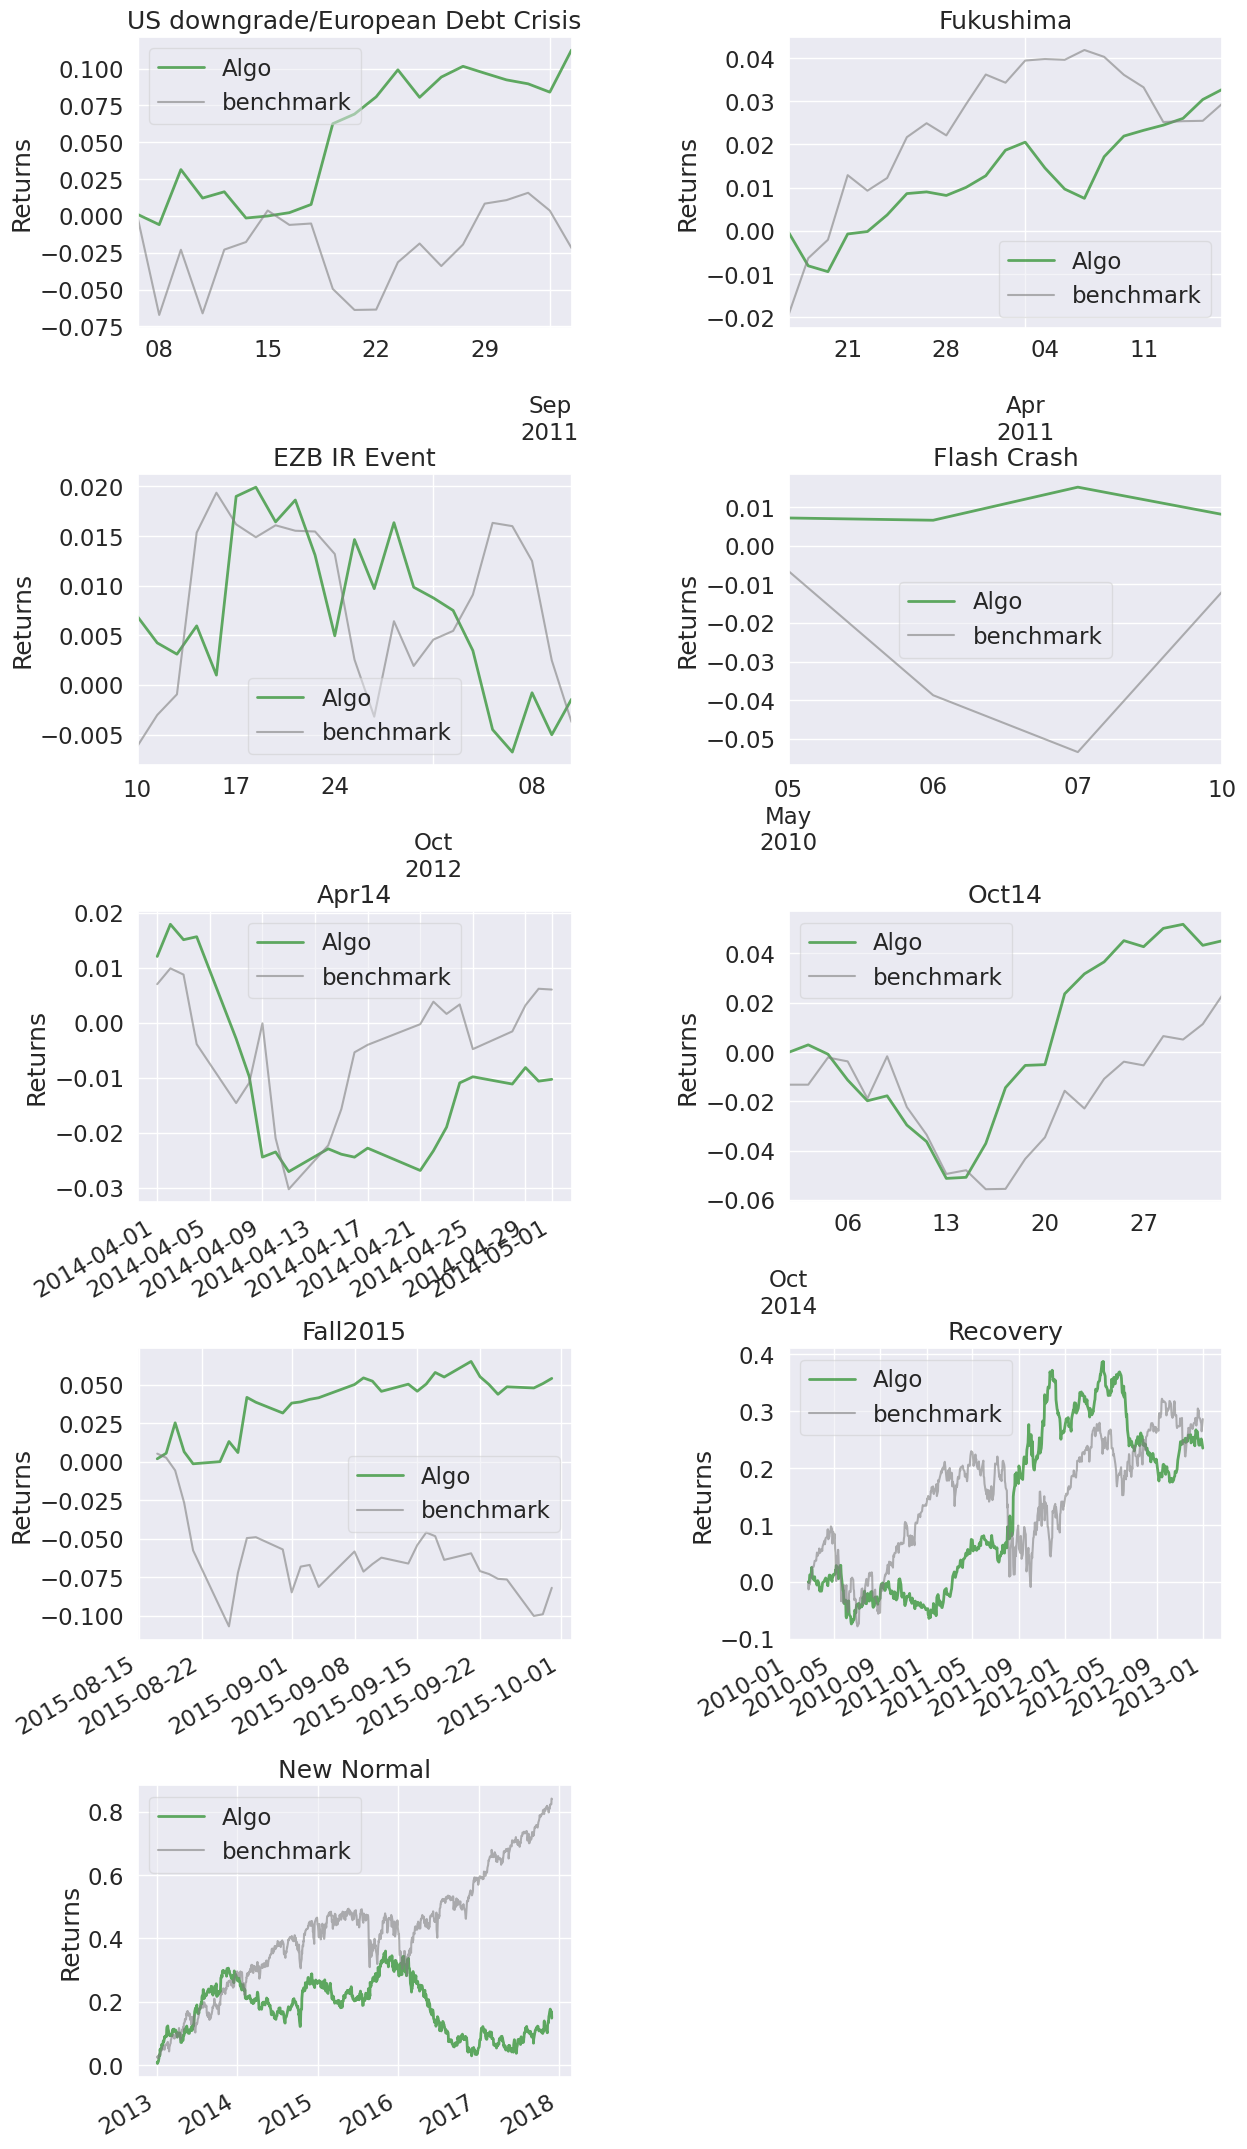

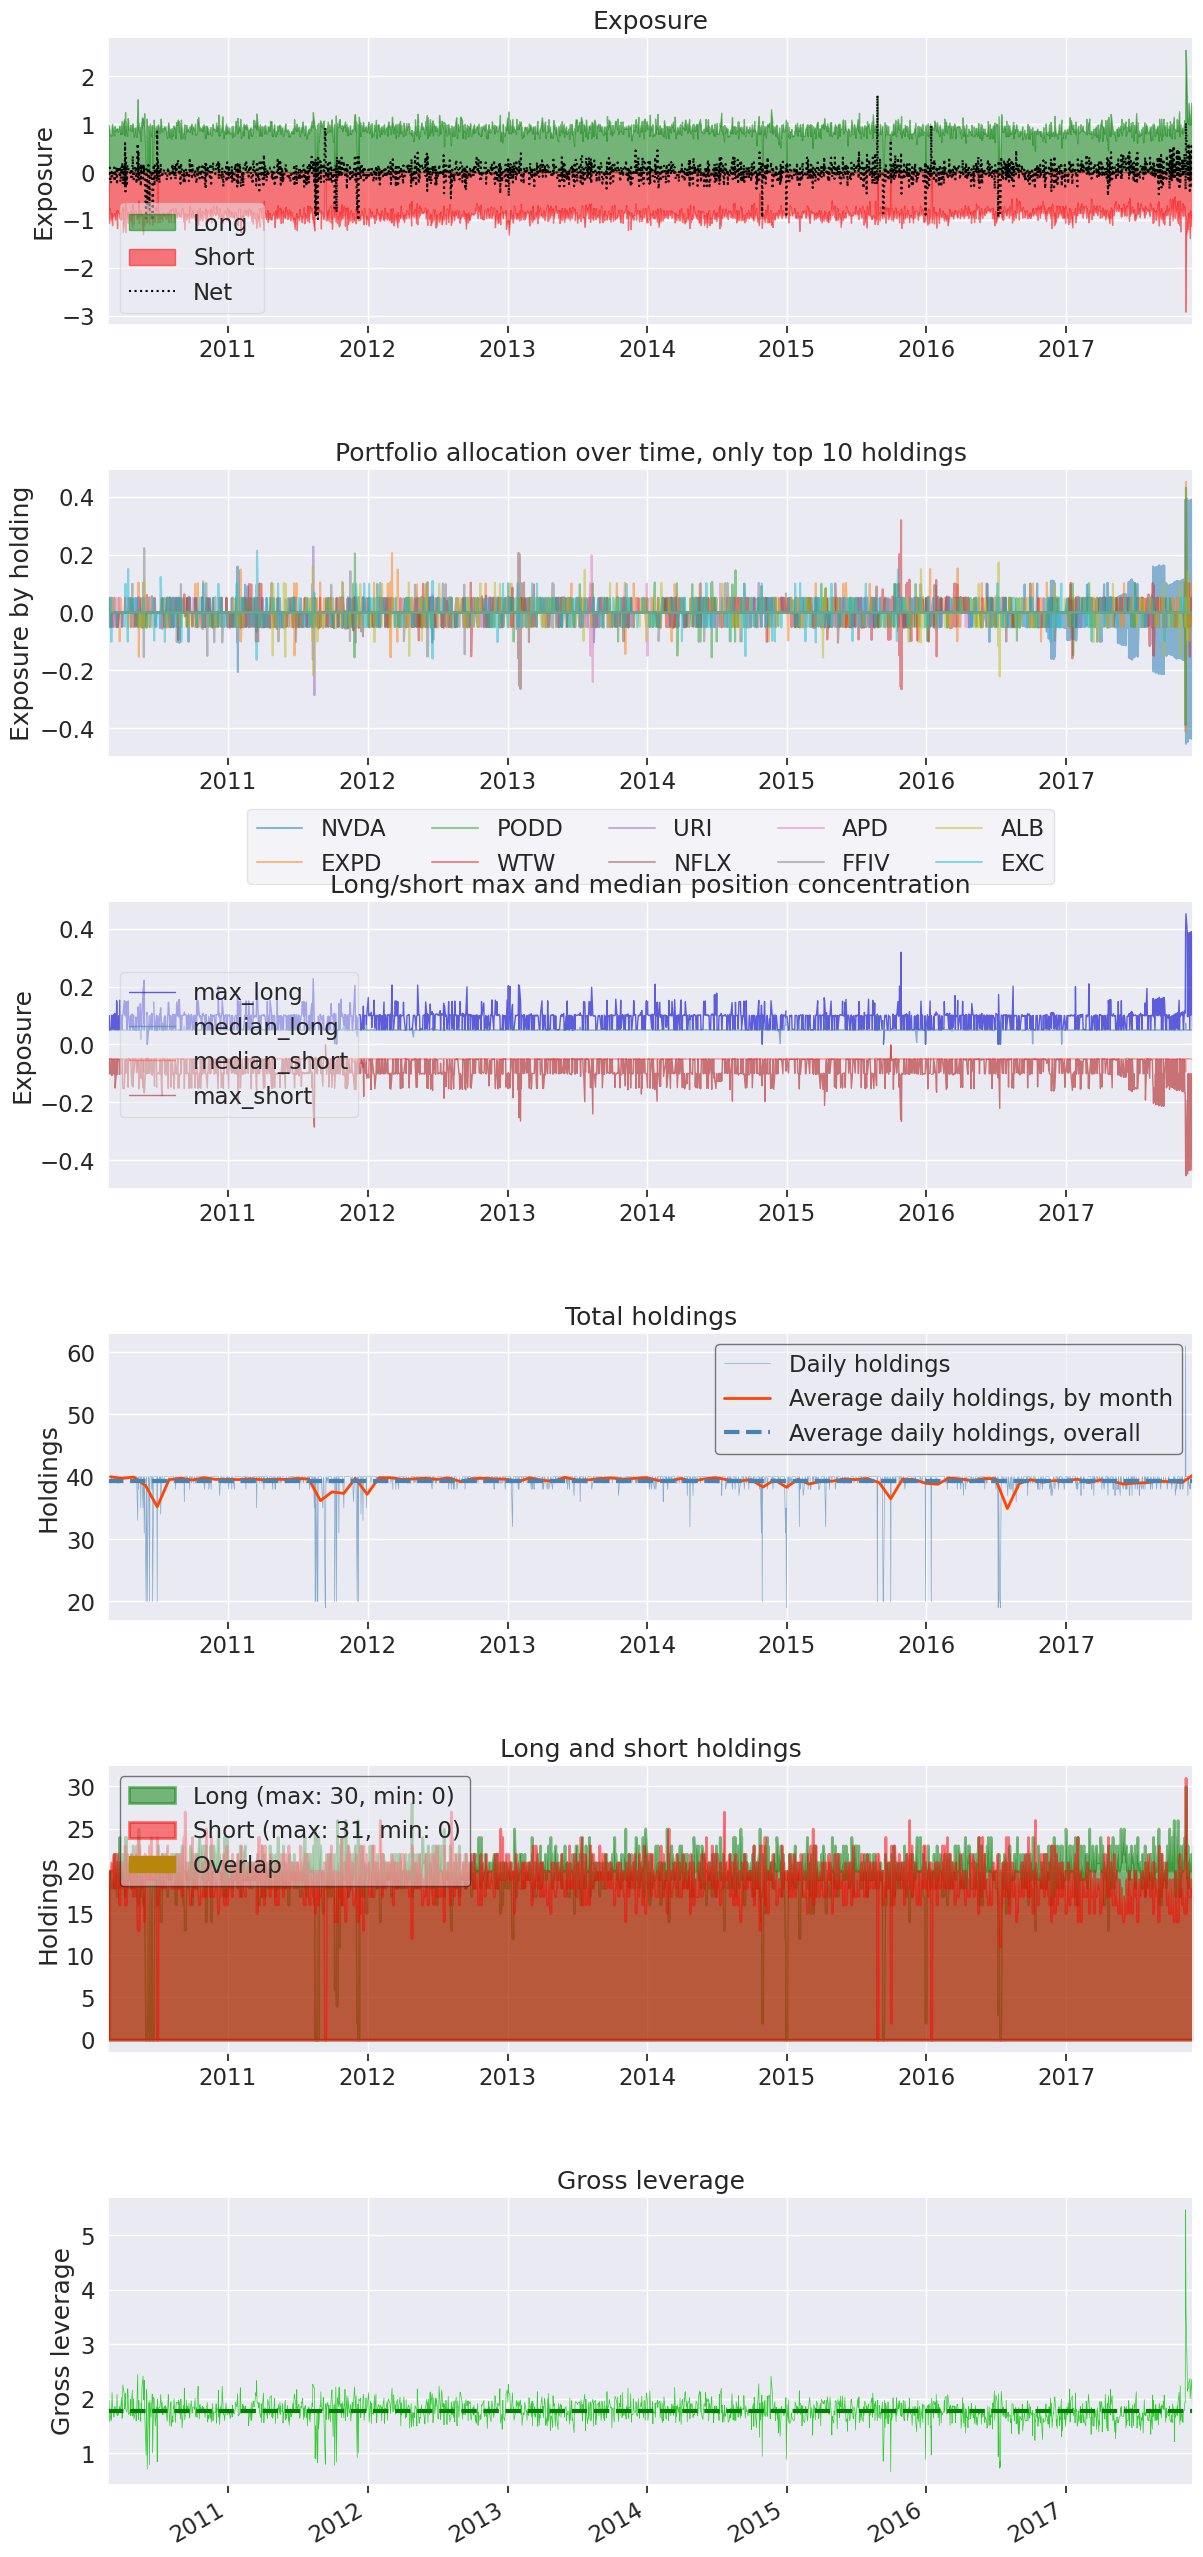

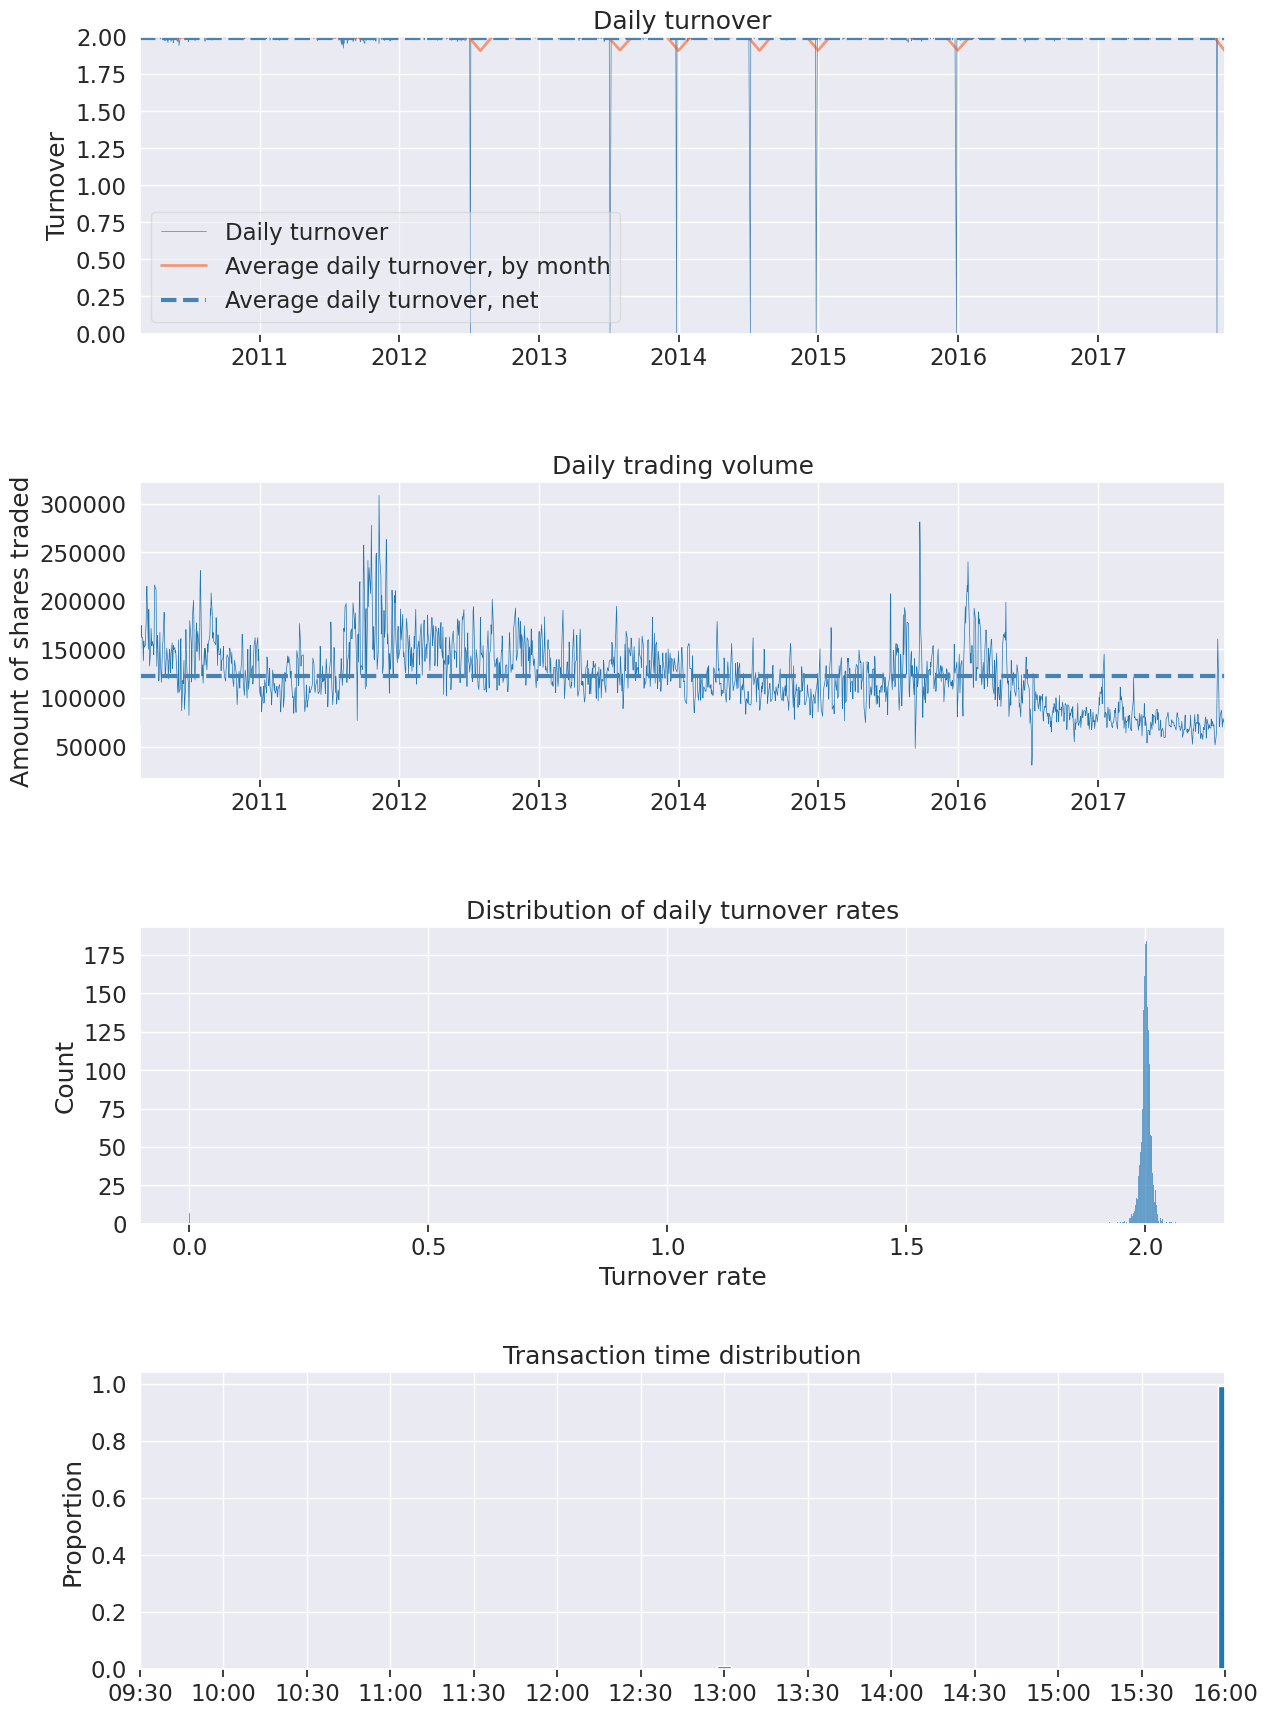

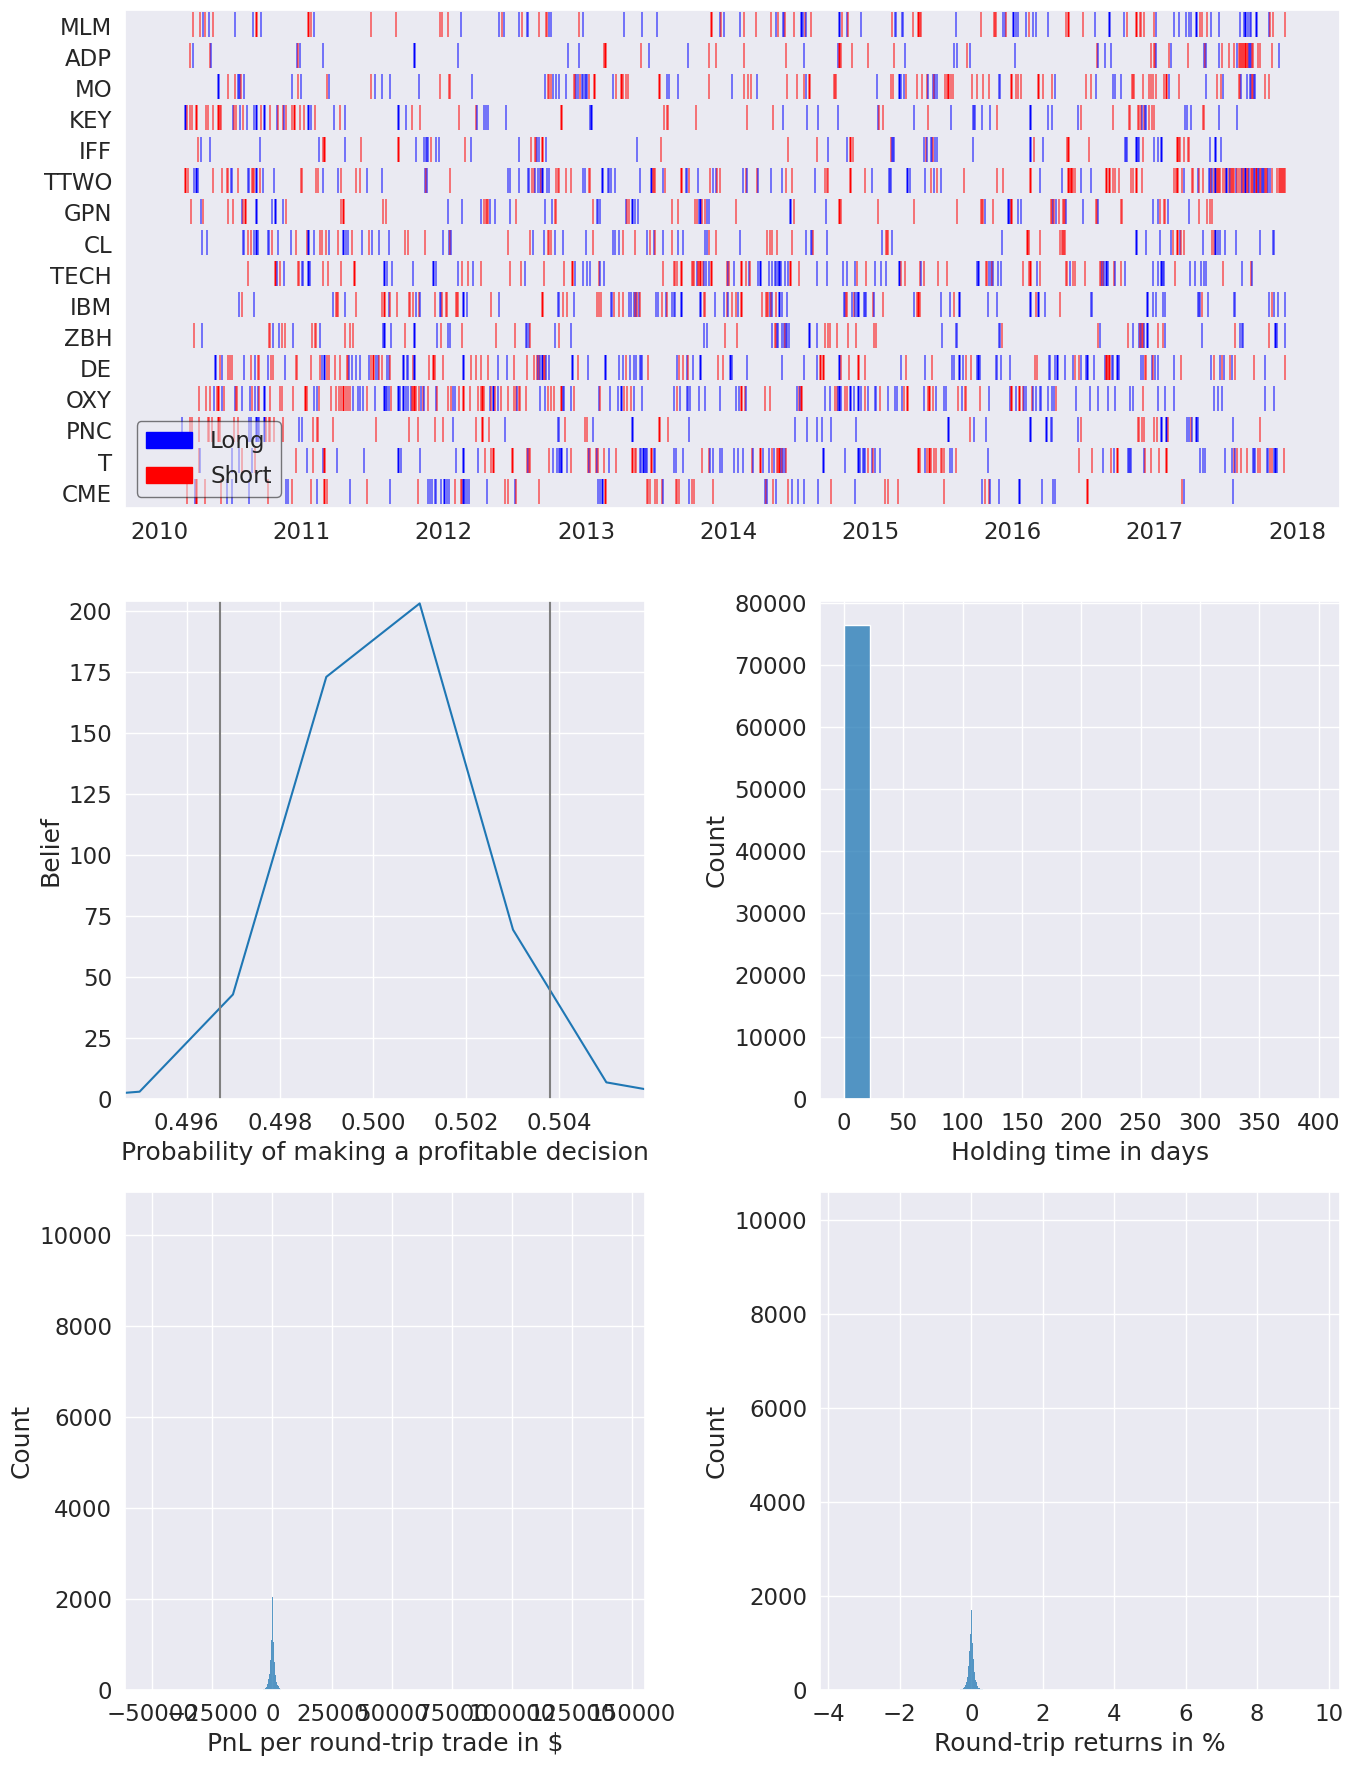

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-8 Factors, we will long and short predictions in quantiles 5 and 4 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":5,
        "quantile_short":4
}

}

In [17]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model8_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

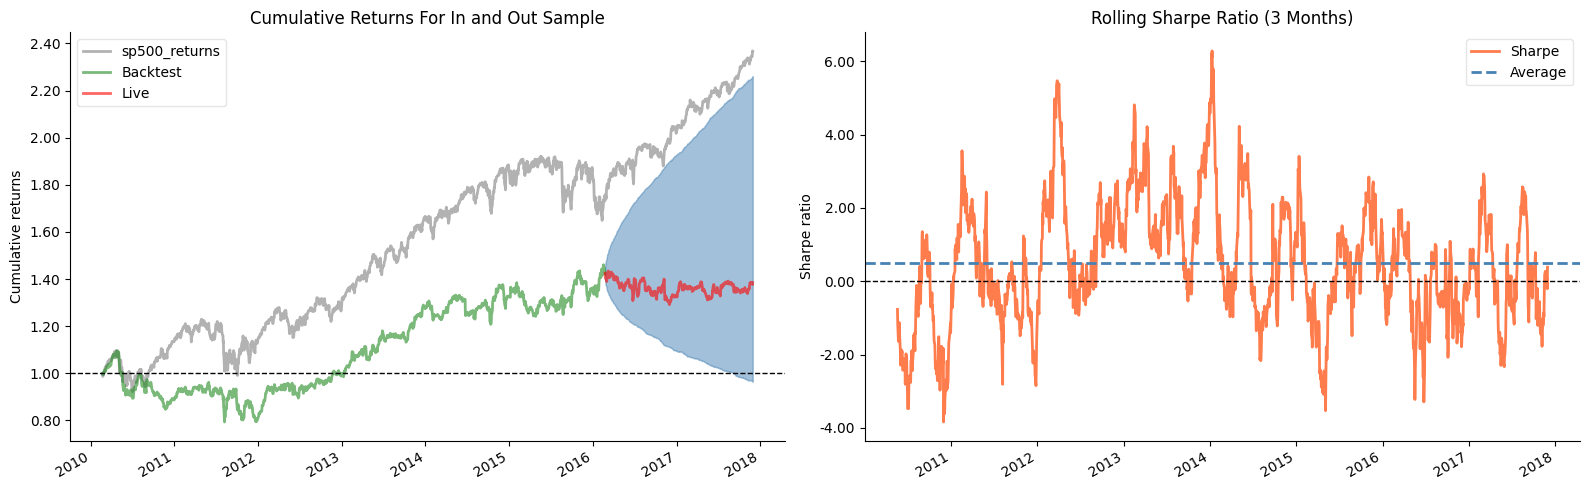

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,27.56,2010-04-29,2011-08-08,2013-03-27,760
1,11.59,2016-02-17,2016-12-01,NaT,NaN
2,10.33,2015-02-03,2015-04-27,2015-10-14,182
3,9.32,2014-05-13,2014-10-13,2014-11-05,127
4,8.84,2015-11-05,2015-12-11,2016-02-10,70


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.40%,-6.82%,7.68%
Fukushima,0.16%,-0.54%,1.19%
EZB IR Event,0.01%,-0.76%,1.57%
Flash Crash,-1.56%,-2.55%,-0.08%
Apr14,0.22%,-1.47%,1.38%
Oct14,0.20%,-2.88%,2.87%
Fall2015,-0.04%,-3.59%,3.23%
Recovery,0.01%,-6.82%,7.68%
New Normal,0.03%,-4.71%,3.23%


Top 10 long positions of all time,max
sid,
VRTX,22.38%
ZBRA,18.06%
AMD,15.83%
STZ,15.39%
FCX,15.39%
AIZ,15.38%
JBL,15.32%
DPZ,15.31%
WRB,15.28%


Top 10 short positions of all time,max
sid,
PHM,-17.23%
HAL,-15.48%
VZ,-15.22%
TER,-15.17%
IP,-15.08%
WRB,-15.05%
WAB,-15.01%
STLD,-14.99%
EMR,-14.96%


Top 10 positions of all time,max
sid,
VRTX,22.38%
ZBRA,18.06%
PHM,17.23%
AMD,15.83%
HAL,15.48%
STZ,15.39%
FCX,15.39%
AIZ,15.38%
JBL,15.32%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$704494.66,$-876473.92,$1580968.58
Gross profit,$19301099.54,$6373341.70,$12927757.85
Gross loss,$-18596604.88,$-7249815.61,$-11346789.27
Profit factor,$1.04,$0.88,$1.14
Avg. trade net profit,$12.04,$-38.98,$43.88
Avg. winning trade,$660.30,$602.17,$693.29
Avg. losing trade,$-645.85,$-618.58,$-664.57
Ratio Avg. Win:Avg. Loss,$1.02,$0.97,$1.04
Largest winning trade,$39696.28,$28075.16,$39696.28
Largest losing trade,$-54082.28,$-54082.28,$-34159.29


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 15:23:07.425724978,1 days 15:19:00.178013963,1 days 15:25:41.729101909
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,175 days 01:00:00,112 days 23:00:00,175 days 01:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.05%,0.06%
Avg returns losing,-0.06%,-0.05%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.03%,0.04%
Median returns losing,-0.04%,-0.03%,-0.04%
Largest winning trade,3.33%,2.51%,3.33%
Largest losing trade,-4.12%,-4.12%,-2.67%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.02%,0.01%,-0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,0.00%,-0.00%,0.02%,-0.01%,-0.01%,0.01%,0.03%,-0.01%,0.01%,-0.00%,0.00%,0.02%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,0.00%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.02%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,-0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,0.02%,-0.00%,0.00%,-0.02%,-0.01%,-0.01%,0.01%,-0.04%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.02%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.00%,0.02%,0.00%,-0.00%,-0.01%,-0.02%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.00%,0.08%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,-0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.02%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.02%,-0.01%,0.00%,0.00%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,0.02%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,-0.01%,0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.01%,0.01%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.00%,-0.02%,-0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.01%,-0.01%,0.01%,0.02%,-0.00%,0.00%,-0.00%,0.01%,-0.00%
Avg returns winning,0.07%,0.0

Profitability (PnL / PnL total) per name,
symbol,
LDOS,22.00%
AOS,7.18%
PODD,6.61%
BBY,6.15%
AME,5.64%
TAP,4.92%
DECK,4.89%
ALGN,4.79%
WYNN,4.45%


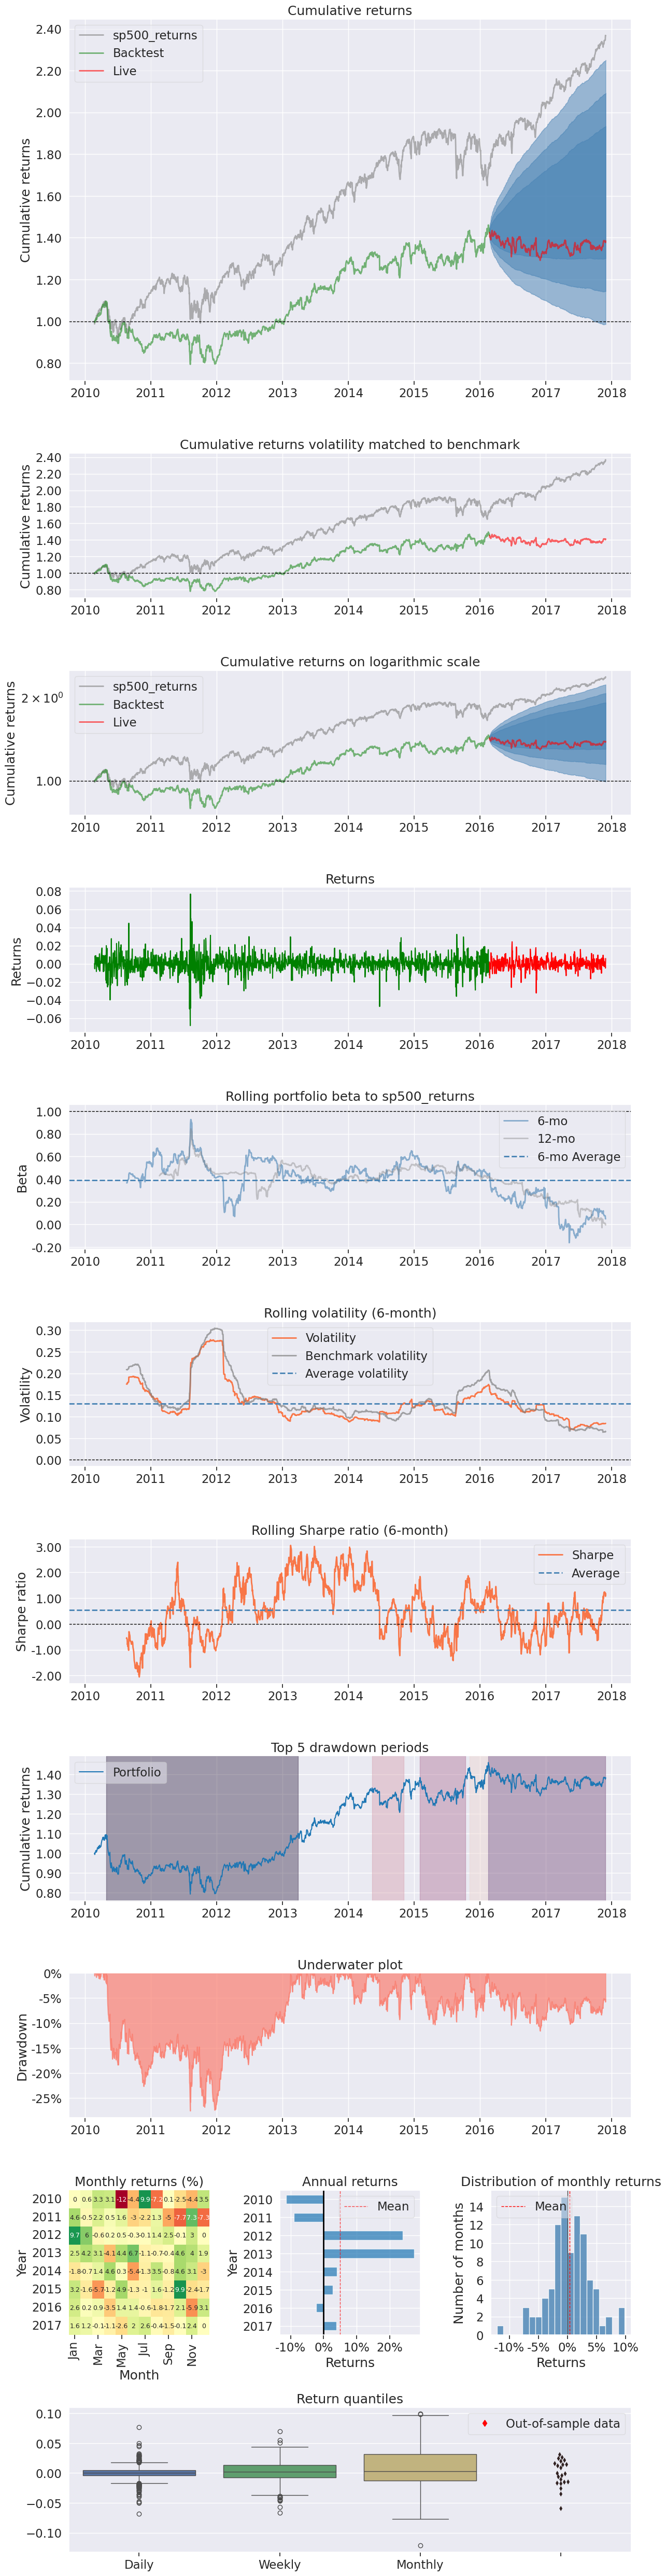

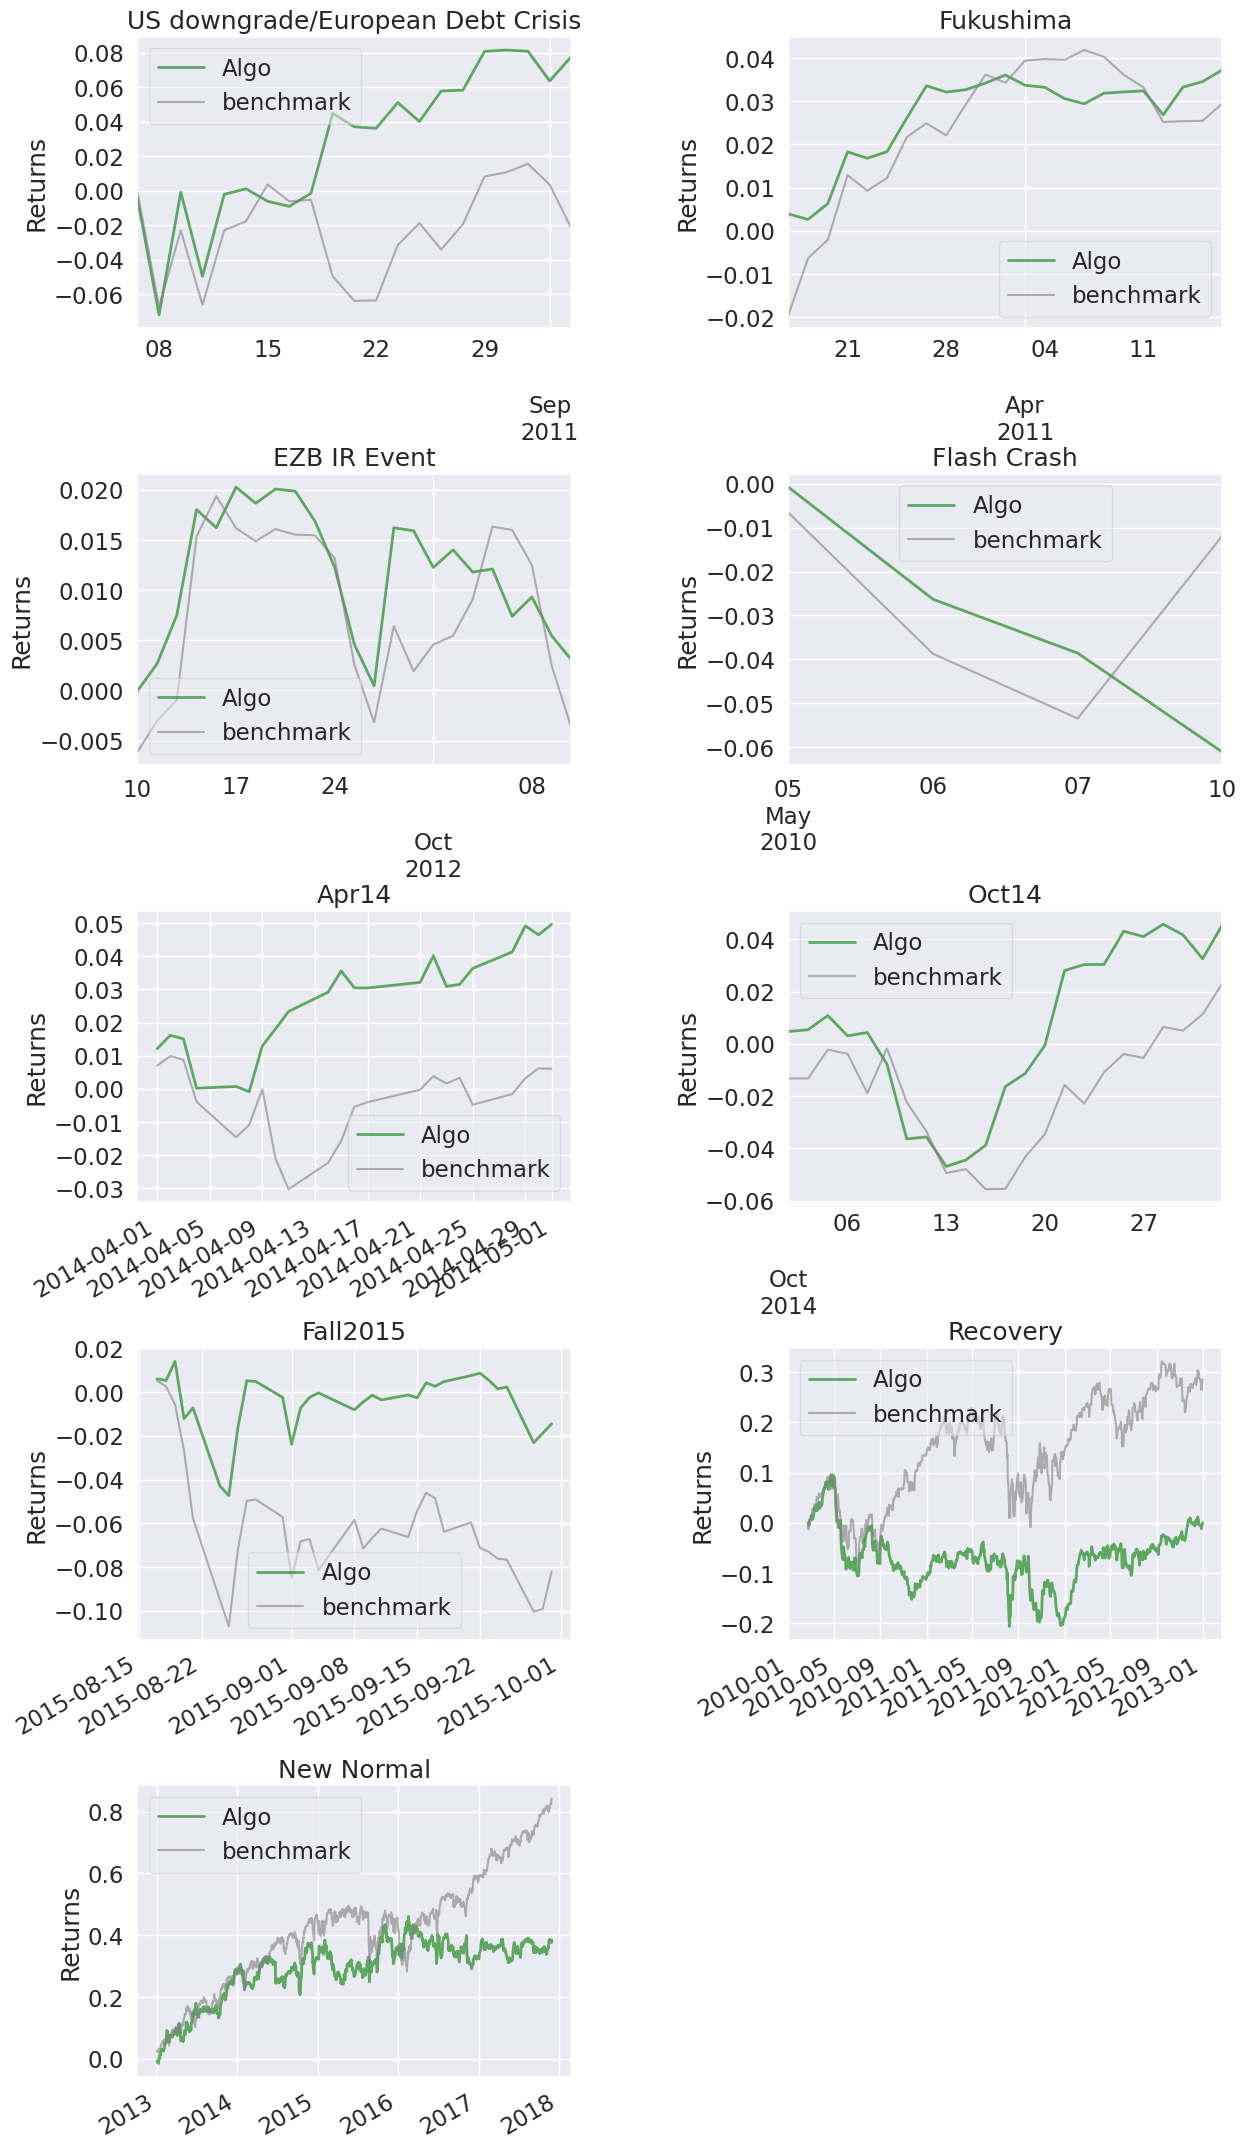

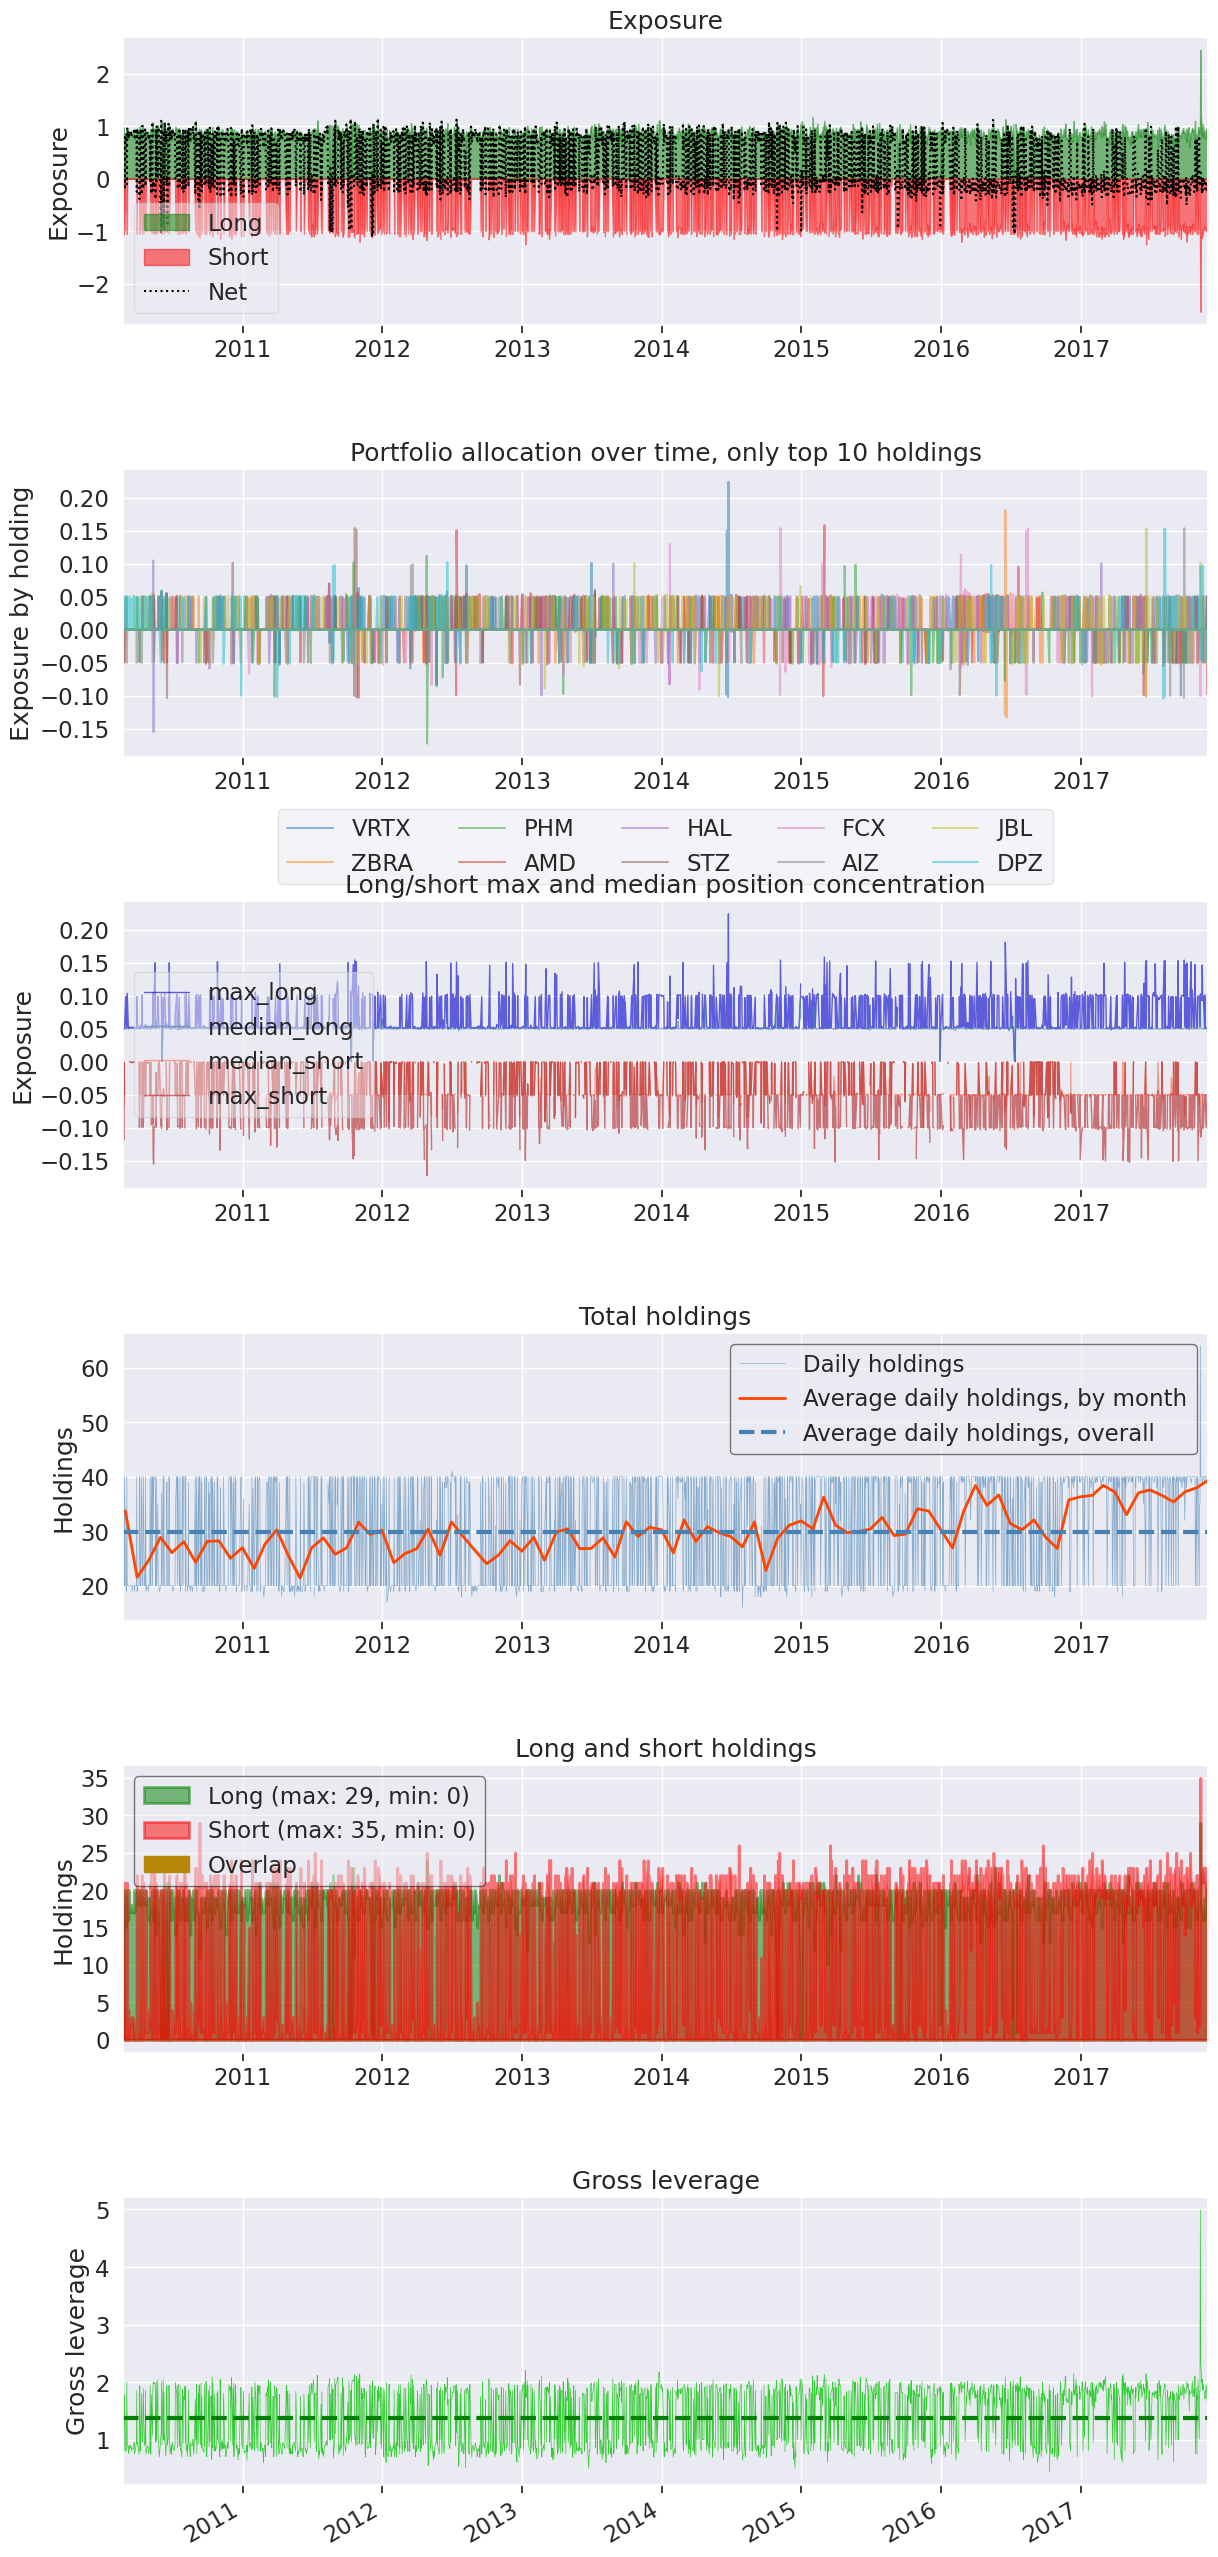

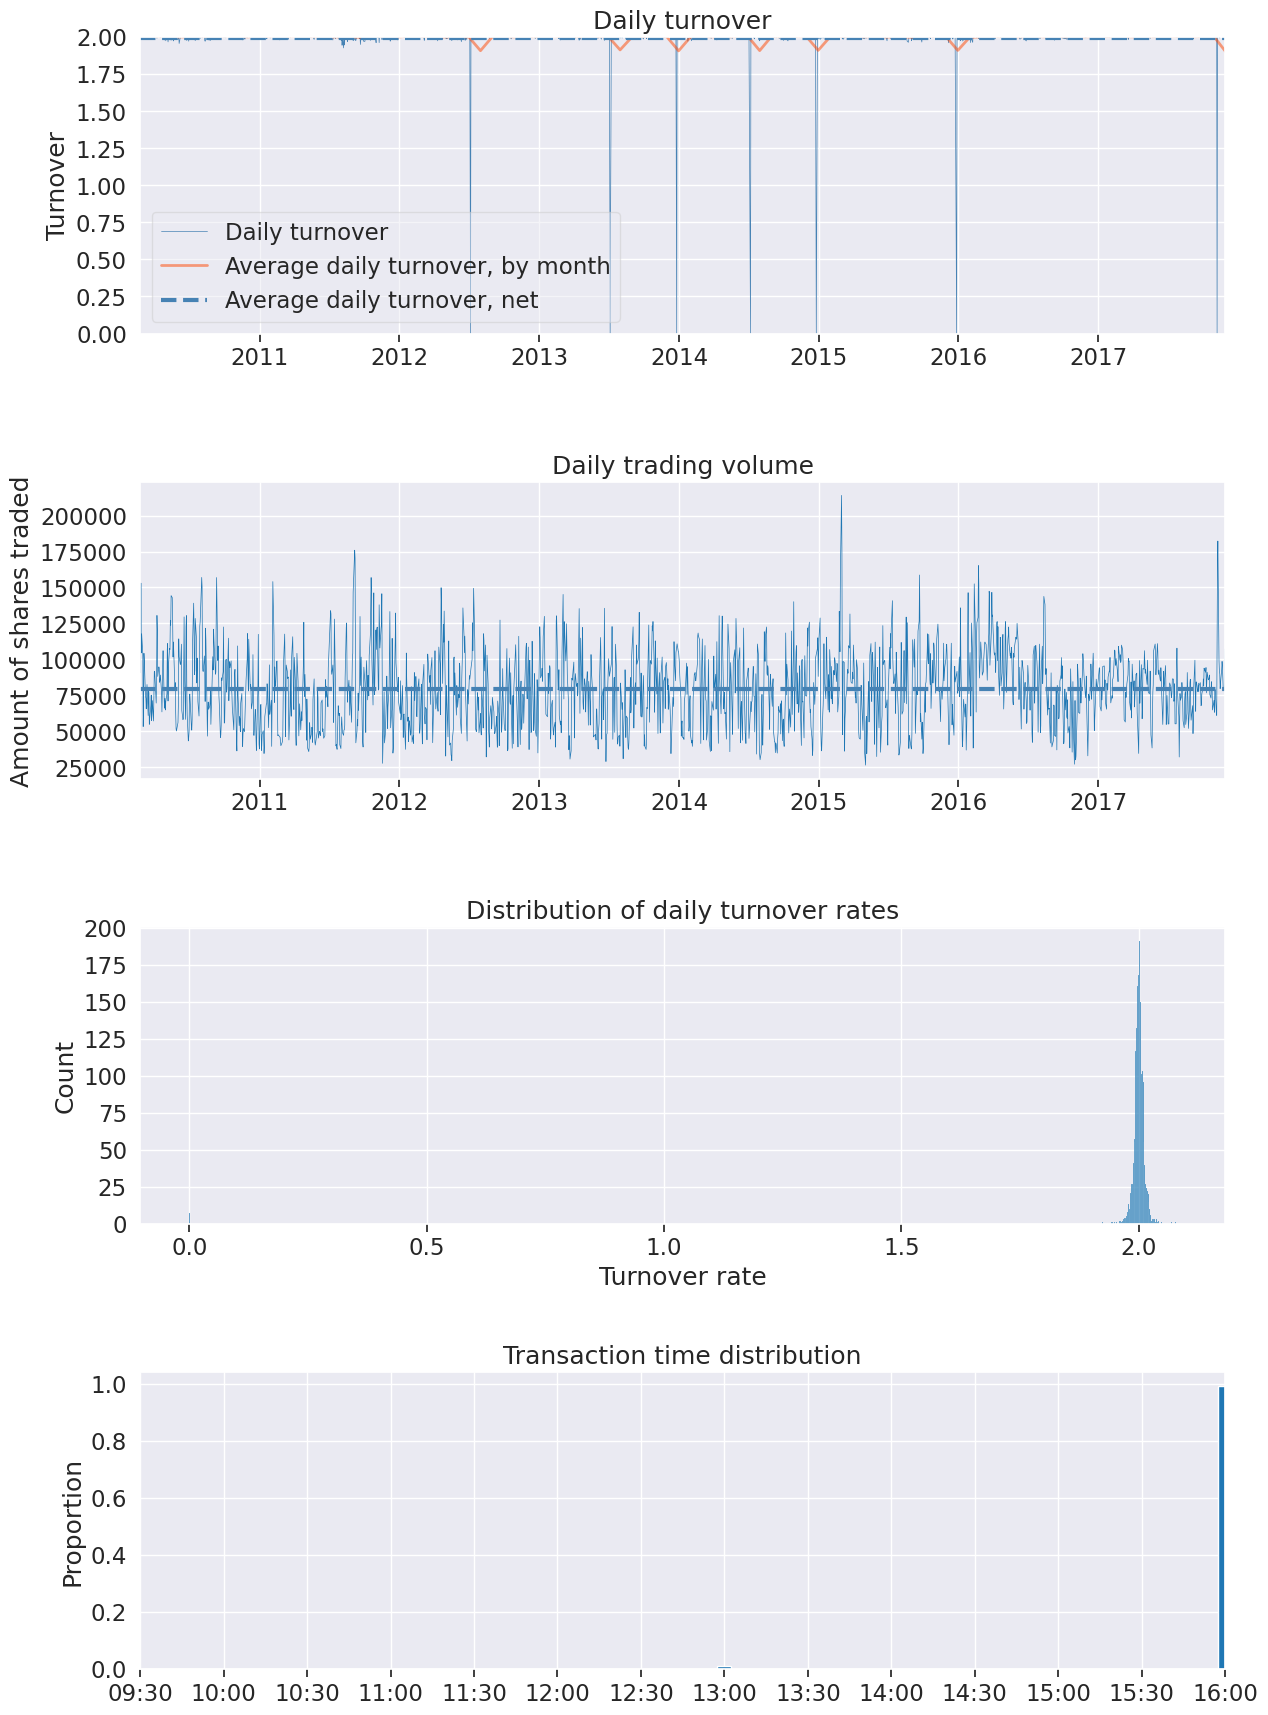

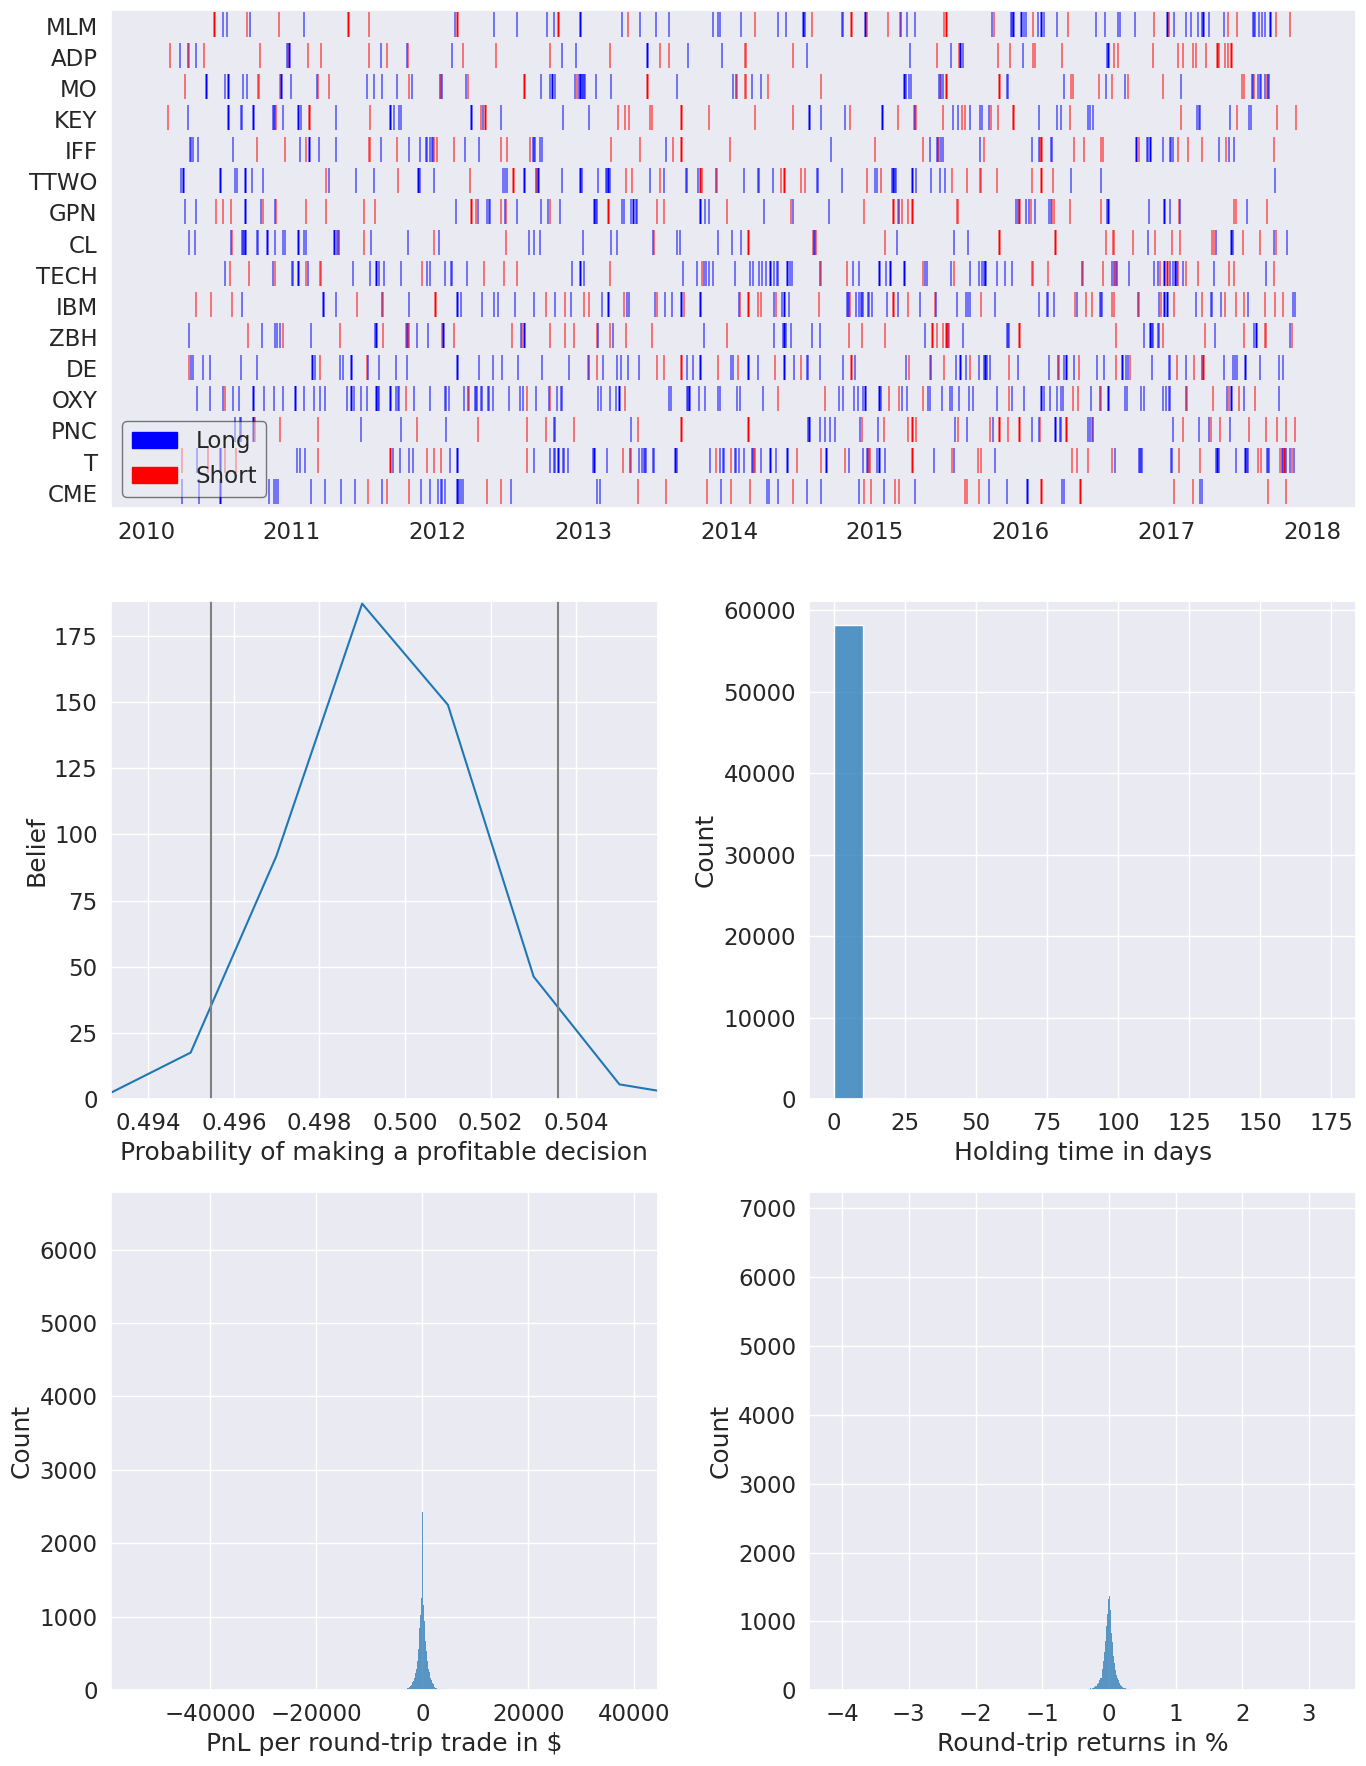

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)